In [284]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [285]:
df = pd.read_csv("Housing.csv")

In [286]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [287]:
df.shape

(545, 13)

In [288]:
cols = df.columns.tolist()
print(cols)

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [289]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [290]:
print(df.isna().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [291]:
X = df.drop('price',axis=1)
Y = df['price']

In [292]:
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [293]:
# pd.get_dummies(df['furnishingstatus'],dtype=int)

In [294]:
categorical = X.iloc[:,4:9]
categorical2 = X.iloc[:,10:12]
all_cat = pd.concat([categorical,categorical2],axis=1)
all_cat

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,yes,no,yes,no,furnished
...,...,...,...,...,...,...,...
540,yes,no,yes,no,no,no,unfurnished
541,no,no,no,no,no,no,semi-furnished
542,yes,no,no,no,no,no,unfurnished
543,no,no,no,no,no,no,furnished


In [295]:
dummies=pd.get_dummies(all_cat,drop_first=True,dtype=int)
dummies

,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1,0,0,0,1,1,0,0
1,1,0,0,0,1,0,0,0
2,1,0,1,0,0,1,1,0
3,1,0,1,0,1,1,0,0
4,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...
540,1,0,1,0,0,0,0,1
541,0,0,0,0,0,0,1,0
542,1,0,0,0,0,0,0,1
543,0,0,0,0,0,0,0,0


In [296]:
X=X.drop(all_cat,axis=1)

In [297]:
X

,area,bedrooms,bathrooms,stories,parking
0,7420,4,2,3,2
1,8960,4,4,4,3
2,9960,3,2,2,2
3,7500,4,2,2,3
4,7420,4,1,2,2
...,...,...,...,...,...
540,3000,2,1,1,2
541,2400,3,1,1,0
542,3620,2,1,1,0
543,2910,3,1,1,0


In [298]:
X=pd.concat([X,dummies],axis=1)
X

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [299]:
#Train test split
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)


In [300]:
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)
# Y_train=pd.DataFrame(Y_train)
# Y_test=pd.DataFrame(Y_test)
# Y_train=sc.fit_transform(Y_train)
# Y_test=sc.transform(Y_test)

In [301]:
# import tensorflow as tf

In [302]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense

In [303]:
# model = Sequential()

In [304]:
# model.add(Dense(units=13,activation='relu'))
# model.add(Dense(units=13,activation='relu'))
# model.add(Dense(units=13,activation='relu'))
# model.add(Dense(units=13,activation='relu'))
# model.add(Dense(1,activation='linear'))

In [305]:
# from sklearn.metrics import accuracy_score

# model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [306]:
# early_stopping=tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     min_delta=0.001,
#     patience=30,
#     verbose=2,
#     mode='auto',
#     baseline=None,
#     restore_best_weights=False,
#     start_from_epoch=0
# )

In [307]:
# model.fit(X_train,Y_train,epochs=40,batch_size=10,validation_split=0.33,callbacks=early_stopping)

In [308]:
from sklearn.ensemble import RandomForestRegressor

In [309]:
model = RandomForestRegressor(n_estimators=500,max_depth=None,random_state=3)

In [310]:
model.fit(X_train,Y_train)

RandomForestRegressor(n_estimators=500, random_state=3)

In [311]:
y_pred = model.predict(X_test)
# print(y_pred[2])
# print(Y_test[2])


In [312]:
from sklearn.metrics import r2_score,mean_absolute_error
print(r2_score(Y_test,y_pred))
print(mean_absolute_error(Y_test,y_pred))

0.6169693064153889
1023162.987706422


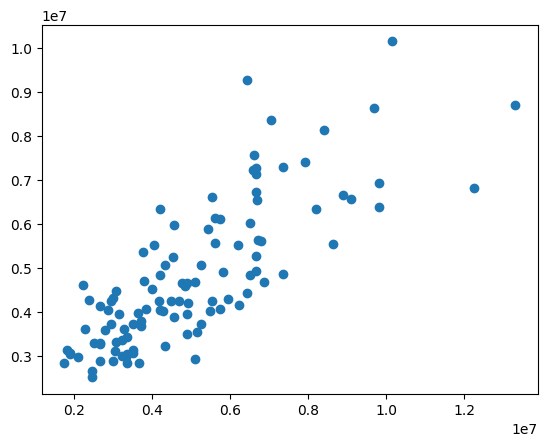

In [313]:
plt.scatter(Y_test,y_pred)

In [314]:
import pickle

# save model
pickle.dump(model, open('model.pkl', 'wb'))

# save scaler (only if used)
pickle.dump(sc, open('scaler.pkl', 'wb'))

# save column order
pickle.dump(X.columns.tolist(), open('columns.pkl', 'wb'))